# How well do jobs and skills pay for Data Analysts?

### Methodology 

1. Evaluate median salary for top 6 data jobs 
2. Find median salary per skill for Data Analysts
3. Visualize for highest paying skills and most demanded skills

In [2]:
# Importing Libraries 
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset
from matplotlib.ticker import FuncFormatter,PercentFormatter
from adjustText import adjust_text

In [3]:
# Loading Data 
raw = load_dataset('lukebarousse/data_jobs')
df = raw['train'].to_pandas().copy()

In [4]:
# Data Cleaning 
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

In [5]:
# Filtering for job postings in the US
df_US = df[(df['job_country']=='United States')].dropna(subset=['salary_year_avg'])

In [6]:
top_6 = df_US['job_title_short'].value_counts().head(6).index.to_list()

In [7]:
df_top_6 = df[df['job_title_short'].isin(top_6)]

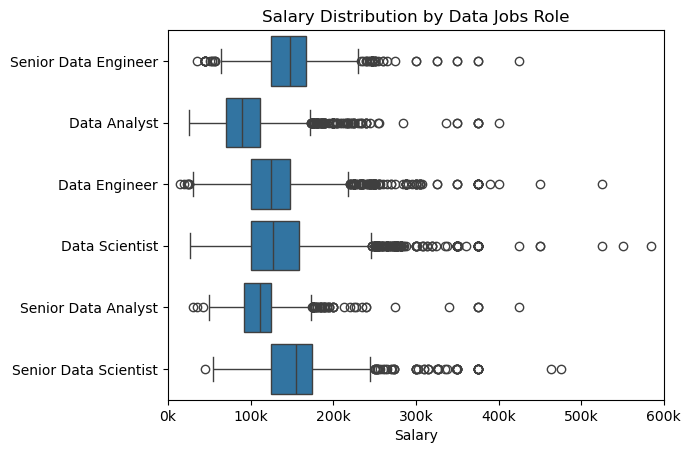

In [8]:
sns.boxplot(data=df_top_6,x='salary_year_avg',y='job_title_short')
plt.ylabel('')
plt.xlabel('Salary')
plt.title('Salary Distribution by Data Jobs Role')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos : f'{int(x/1000)}k'))
plt.xlim(0,600000)
plt.show()


In [9]:
job_orders = df_top_6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index.to_list()

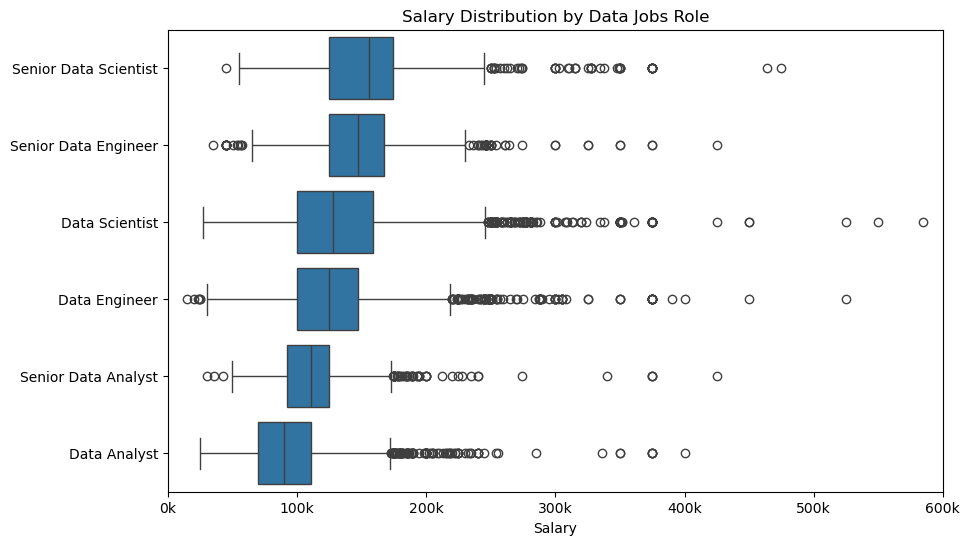

In [10]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df_top_6,x='salary_year_avg',y='job_title_short',order=job_orders)
plt.ylabel('')
plt.xlabel('Salary')
plt.title('Salary Distribution by Data Jobs Role')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos : f'{int(x/1000)}k'))
plt.xlim(0,600000)
plt.show()


## Investigate Median Salary Vs Skills for Data Analysts

In [21]:
# Filtering job posting for Data Analysts in the US
df_DA_US = df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='United States')]
df_DA_US.dropna(subset='salary_year_avg',inplace=True)

In [22]:
df_explode = df_DA_US.explode('job_skills')

In [23]:
df_grp = df_explode.groupby('job_skills')['salary_year_avg'].agg(['count','median'])
df_grp

,count,median
job_skills,,
airflow,44,116250.00
airtable,5,90000.00
alteryx,106,106281.25
angular,8,107500.00
ansible,1,159640.00
...,...,...
wire,4,74250.00
word,461,81194.75
workfront,3,75000.00


In [44]:
top_pay = df_grp.sort_values(by='median',ascending=False).head(10)
top_pay.drop('count',axis=1,inplace=True)
top_pay

,median
job_skills,
dplyr,196250.0
bitbucket,189000.0
gitlab,186000.0
solidity,179000.0
hugging face,175000.0
couchbase,160515.0
ansible,159640.0
mxnet,149000.0
cassandra,148250.0


In [73]:
top_skills = df_grp.sort_values(by='count',ascending=False).head(10)
top_skills = top_skills.sort_values(by='median',ascending=False)
top_skills

,count,median
job_skills,,
python,1431,97500.00
tableau,1364,92875.00
r,893,92500.00
sql server,286,92500.00
sql,2508,91000.00
sas,926,90000.00
power bi,838,90000.00
powerpoint,462,85000.00
excel,1808,84392.00


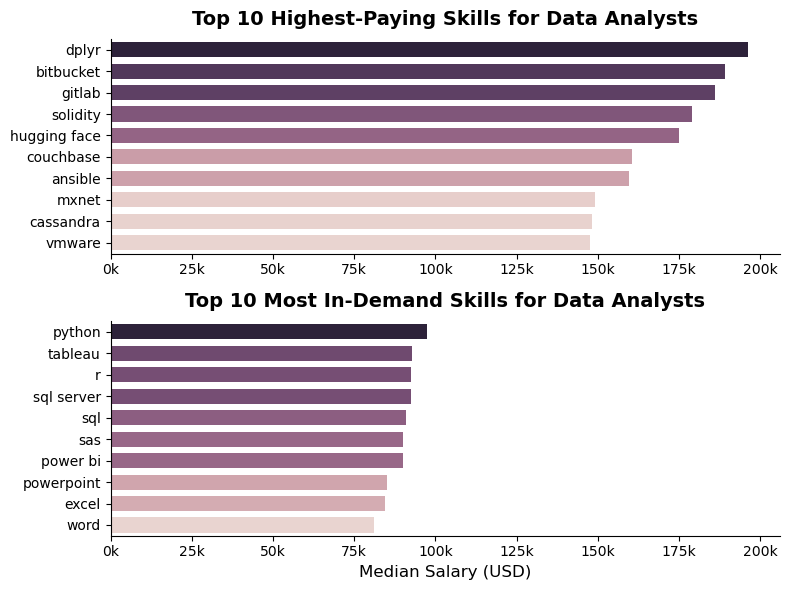

In [80]:
top_pay_series = top_pay['median']
top_skills_series = top_skills['median']

top_list =[top_pay_series,top_skills_series]
titles = [
    "Top 10 Highest-Paying Skills for Data Analysts",
    "Top 10 Most In-Demand Skills for Data Analysts"
]

fig, ax = plt.subplots(2,1,figsize=(8,6))

for i,(data,title) in enumerate(zip(top_list,titles)):
    sns.barplot(
        y=data.index,
        x=data.values,
        ax=ax[i],
        hue=data.values,
        width=0.7
            )
        
    ax[i].set_title(title, fontsize=14, fontweight='bold', pad=10)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].legend().remove()
    ax[i].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x/1000)}k'))

    ax[1].set_xlim(ax[0].get_xlim())
    ax[1].set_xlabel('Median Salary (USD)',fontsize=12)
                   
    sns.despine()
    
plt.tight_layout()
plt.show()